# Projet COVID 19 : Modelisation Random Forest - 4 classes - Unbalanced - 3ème itération

## Conditions de modélisation

## Environnement de travail

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve,
    average_precision_score
)

from sklearn.inspection import permutation_importance
import joblib

In [6]:
# Répertoire du notebook
NOTEBOOK_DIR = Path.cwd()

# Racine du projet (Liora_Covid)
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent

# Dossier des CSV
DATA_DIR = PROJECT_ROOT / "csv"

print("Notebook :", NOTEBOOK_DIR)
print("Projet   :", PROJECT_ROOT)
print("CSV      :", DATA_DIR)

Notebook : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\Liora_Covid\models\random_forest
Projet   : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\Liora_Covid
CSV      : C:\Users\n_a_e\Documents\DataScientest\Data Scientist\Projet COVID\Liora_Covid\csv


In [7]:
# Chargement des données
train = pd.read_csv(DATA_DIR / "train_features.csv")
validation = pd.read_csv(DATA_DIR / "validation_features.csv")
test = pd.read_csv(DATA_DIR / "test_features.csv")

print(f"\nTrain      : {train.shape}")
print(f"Validation : {validation.shape}")
print(f"Test       : {test.shape}")


Train      : (16668, 6)
Validation : (2083, 6)
Test       : (2084, 6)


## Définition de la cible et des features

In [8]:
target = "classe"

features = [
    "lum_interieur_masque",
    "lum_exterieur_masque",
    "surface_masque",
    "variance_laplacien"
]

target = "classe"

X_train = train[features]
y_train = train[target]

X_val = validation[features]
y_val = validation[target]

X_test = test[features]
y_test = test[target]

## Vérification des classes

In [9]:
print("Distribution train :")
print(y_train.value_counts(normalize=True))

print("\nDistribution validation :")
print(y_val.value_counts(normalize=True))

print("\nDistribution test :")
print(y_test.value_counts(normalize=True))

Distribution train :
classe
Normal             0.486501
Lung_Opacity       0.287437
COVID              0.161867
Viral Pneumonia    0.064195
Name: proportion, dtype: float64

Distribution validation :
classe
Normal             0.486318
Lung_Opacity       0.287086
COVID              0.162266
Viral Pneumonia    0.064330
Name: proportion, dtype: float64

Distribution test :
classe
Normal             0.486564
Lung_Opacity       0.287428
COVID              0.161708
Viral Pneumonia    0.064299
Name: proportion, dtype: float64


## Pipeline Random Forest

In [10]:
rf_pipe = Pipeline([
    ("model",
     RandomForestClassifier(
         n_estimators=200,
         max_depth=20,
         min_samples_split=15,
         min_samples_leaf=4,
         random_state=0,
         n_jobs=-1
     ))
])

In [11]:
rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('model',
                 RandomForestClassifier(max_depth=20, min_samples_leaf=4,
                                        min_samples_split=15, n_estimators=200,
                                        n_jobs=-1, random_state=0))])

In [13]:
y_val_pred = rf_pipe.predict(X_val)

## Évaluation sur validation

### Classification report

In [14]:
y_val_pred = rf_pipe.predict(X_val)
y_val_proba = rf_pipe.predict_proba(X_val)

print("Évaluation sur le jeu de validation")
print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Balanced accuracy :", balanced_accuracy_score(y_val, y_val_pred))
print("Precision macro :", precision_score(y_val, y_val_pred, average="macro"))
print("Recall macro :", recall_score(y_val, y_val_pred, average="macro"))
print("F1-score macro :", f1_score(y_val, y_val_pred, average="macro"))
print("F1-score weighted :", f1_score(y_val, y_val_pred, average="weighted"))

print("\nRapport de classification :")
print(classification_report(y_val, y_val_pred))

Évaluation sur le jeu de validation
Accuracy : 0.6101776284205472
Balanced accuracy : 0.45145991023081333
Precision macro : 0.5215231053624387
Recall macro : 0.45145991023081333
F1-score macro : 0.45260532956170174
F1-score weighted : 0.5648384489326578

Rapport de classification :
                 precision    recall  f1-score   support

          COVID       0.36      0.07      0.12       338
   Lung_Opacity       0.56      0.55      0.56       598
         Normal       0.65      0.86      0.74      1013
Viral Pneumonia       0.51      0.32      0.39       134

       accuracy                           0.61      2083
      macro avg       0.52      0.45      0.45      2083
   weighted avg       0.57      0.61      0.56      2083



La suppression des class weights améliore l'accuracy globale (0,610 contre 0,574), mais cette amélioration est essentiellement due à une meilleure reconnaissance de la classe majoritaire Normal. En contrepartie, les performances chutent nettement sur les classes minoritaires, en particulier COVID (F1 : 0,12) et Viral Pneumonia (F1 : 0,39). Cette dégradation se traduit par une baisse du Balanced Accuracy (0,451) et du F1 macro (0,453), indiquant une perte d'équilibre entre les classes. Les poids de classes permettent donc de mieux répartir les performances au détriment d'une légère baisse de l'accuracy globale.

### Matrice de confusion

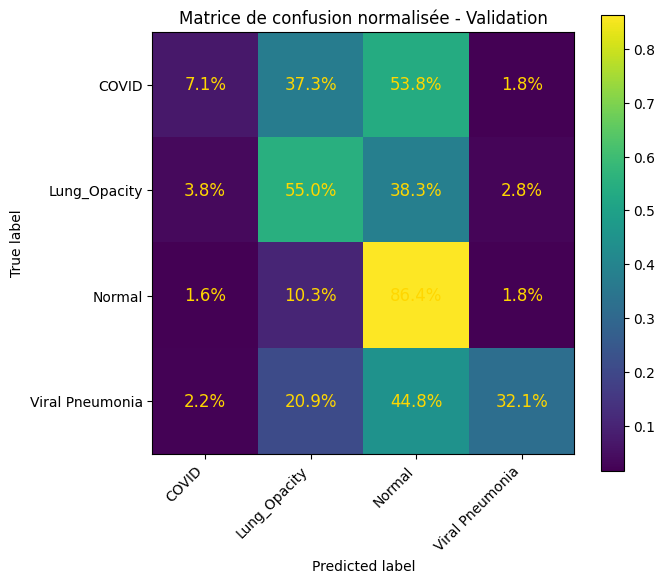

In [15]:
# Matrice de confusion normalisée (par ligne = classe réelle)
cm_norm = confusion_matrix(
    y_val,
    y_val_pred,
    labels=rf_pipe.named_steps["model"].classes_,
    normalize="true"
)

class_names = rf_pipe.named_steps["model"].classes_

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm_norm, interpolation="nearest", cmap="viridis")
plt.colorbar(im, ax=ax)

# Axes
ax.set(
    xticks=np.arange(len(class_names)),
    yticks=np.arange(len(class_names)),
    xticklabels=class_names,
    yticklabels=class_names,
    xlabel="Predicted label",
    ylabel="True label",
    title="Matrice de confusion normalisée - Validation"
)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Affichage des pourcentages
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm_norm[i, j]*100:.1f}%",
            ha="center",
            va="center",
            color="gold",
            fontsize=12
        )

plt.tight_layout()
plt.show()

le modèle présente un fort biais en faveur de la classe Normal, qu'il prédit fréquemment au détriment des trois classes pathologiques, en particulier COVID, dont la sensibilité est très faible. Cela explique le faible rappel observé pour cette classe dans les métriques de validation.

### Features importance

In [16]:
rf_model = rf_pipe.named_steps["model"]

importances = rf_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

feature_importance_df.head(20)

,feature,importance
3,variance_laplacien,0.406470
2,surface_masque,0.224000
0,lum_interieur_masque,0.212443
1,lum_exterieur_masque,0.157087


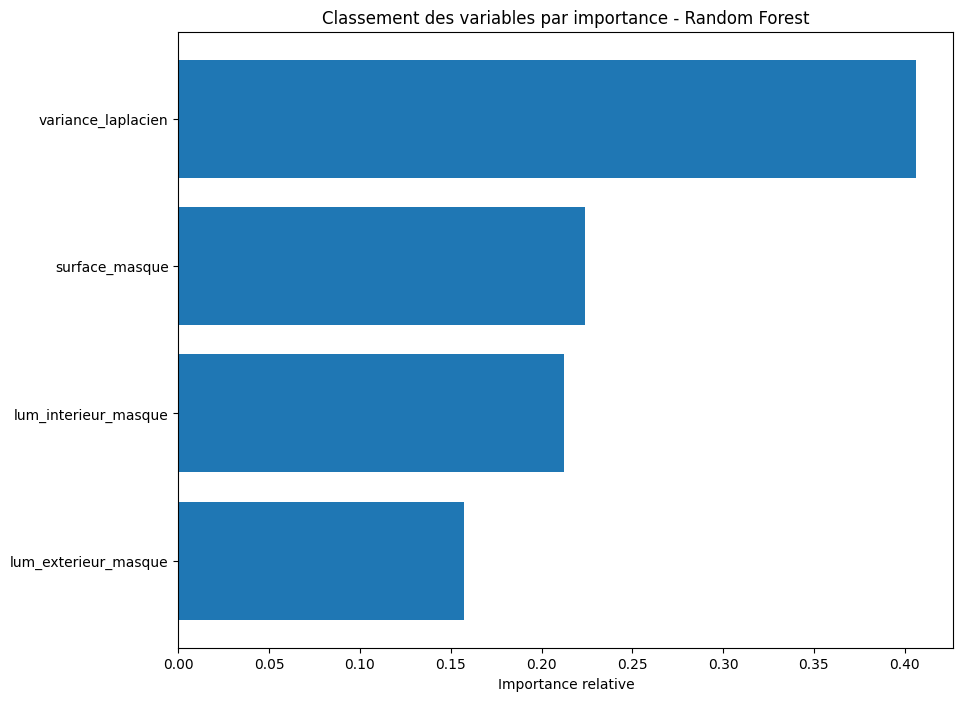

In [17]:
plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance_df["feature"][::-1],
    feature_importance_df["importance"][::-1]
)
plt.xlabel("Importance relative")
plt.title("Classement des variables par importance - Random Forest")
plt.show()

La variance du Laplacien est la variable la plus discriminante (≈ 0,41), ce qui souligne l'importance des informations de texture et de netteté dans la classification. Les variables surface du masque (≈ 0,22) et luminosité intérieure du masque (≈ 0,21) apportent également une contribution significative. En revanche, la luminosité extérieure du masque est la moins influente (≈ 0,16), indiquant un pouvoir discriminant plus limité pour le modèle.

### Permutation importance

In [16]:
perm_importance = permutation_importance(
    rf_pipe,
    X_val,
    y_val,
    scoring="f1_macro",
    n_repeats=10,
    random_state=0,
    n_jobs=-1
)

In [17]:
perm_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
})

perm_df = perm_df.sort_values(
    by="importance_mean",
    ascending=False
).reset_index(drop=True)

perm_df.head(20)

,feature,importance_mean,importance_std
0,variance_laplacien,0.145859,0.011378
1,lum_interieur_masque,0.097828,0.004471
2,surface_masque,0.064179,0.010881
3,lum_exterieur_masque,0.020479,0.006194


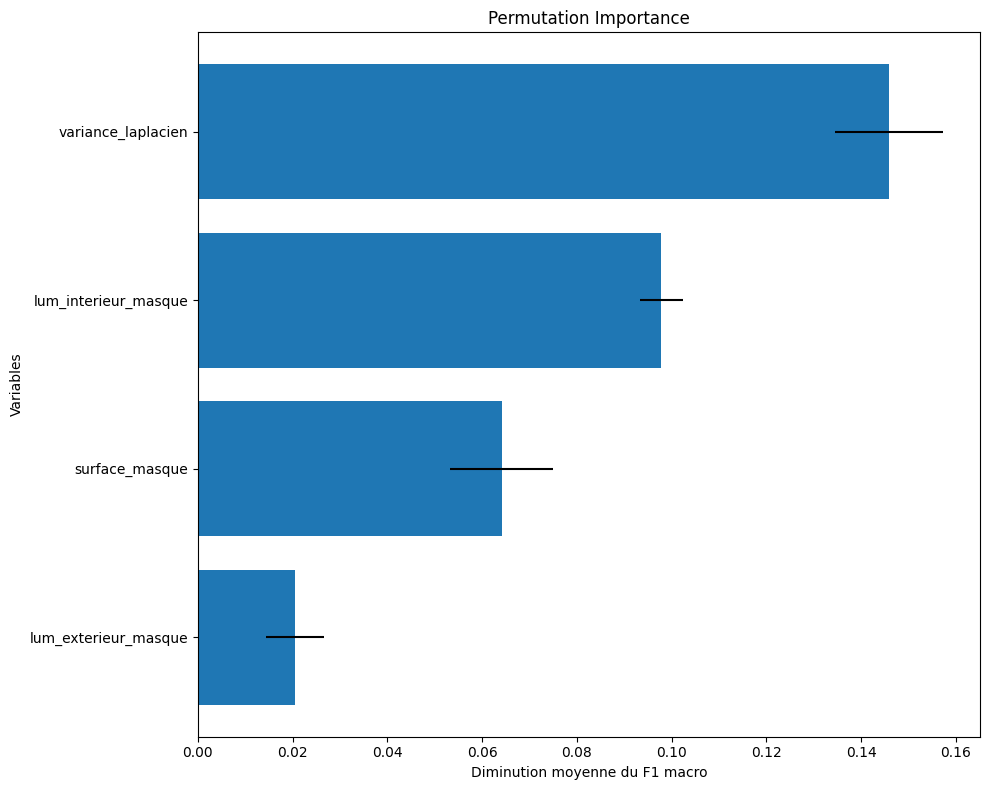

In [18]:
plt.figure(figsize=(10,8))

plt.barh(
    perm_df["feature"][:20][::-1],
    perm_df["importance_mean"][:20][::-1],
    xerr=perm_df["importance_std"][:20][::-1]
)

plt.xlabel("Diminution moyenne du F1 macro")
plt.ylabel("Variables")
plt.title("Permutation Importance")

plt.tight_layout()
plt.show()

La variance du Laplacien est la variable la plus influente, suivie de la luminosité intérieure et de la surface du masque. La luminosité extérieure contribue peu aux performances du modèle.

## Évaluation sur test

### Classification report

In [21]:
# Prédictions finales sur le jeu de test
y_test_pred = rf_pipe.predict(X_test)
y_test_proba = rf_pipe.predict_proba(X_test)

class_names = rf_pipe.named_steps["model"].classes_

print("Évaluation finale sur le jeu de test\n")

print(f"Accuracy           : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Balanced accuracy  : {balanced_accuracy_score(y_test, y_test_pred):.4f}")

print(
    f"Precision macro    : "
    f"{precision_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}"
)

print(
    f"Recall macro       : "
    f"{recall_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}"
)

print(
    f"F1-score macro     : "
    f"{f1_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}"
)

print(
    f"F1-score weighted  : "
    f"{f1_score(y_test, y_test_pred, average='weighted', zero_division=0):.4f}"
)

print("\nRapport de classification :\n")

print(
    classification_report(
        y_test,
        y_test_pred,
        labels=class_names,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

Évaluation finale sur le jeu de test

Accuracy           : 0.6089
Balanced accuracy  : 0.4628
Precision macro    : 0.5508
Recall macro       : 0.4628
F1-score macro     : 0.4673
F1-score weighted  : 0.5685

Rapport de classification :

                 precision    recall  f1-score   support

          COVID     0.4697    0.0920    0.1538       337
   Lung_Opacity     0.5423    0.5559    0.5491       599
         Normal     0.6517    0.8452    0.7359      1014
Viral Pneumonia     0.5393    0.3582    0.4305       134

       accuracy                         0.6089      2084
      macro avg     0.5508    0.4628    0.4673      2084
   weighted avg     0.5836    0.6089    0.5685      2084



En résumé, la suppression des class weights favorise les classes majoritaires, notamment "Normal", mais dégrade fortement la sensibilité du modèle aux classes rares, en particulier COVID.

### Matrice de confusion

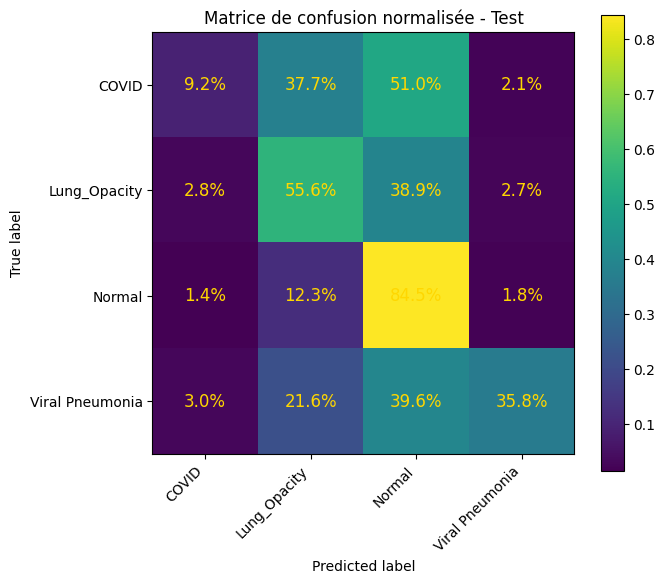

In [22]:
# Matrice de confusion normalisée (par ligne = classe réelle)
cm_norm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=rf_pipe.named_steps["model"].classes_,
    normalize="true"
)

class_names = rf_pipe.named_steps["model"].classes_

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm_norm, interpolation="nearest", cmap="viridis")
plt.colorbar(im, ax=ax)

# Axes
ax.set(
    xticks=np.arange(len(class_names)),
    yticks=np.arange(len(class_names)),
    xticklabels=class_names,
    yticklabels=class_names,
    xlabel="Predicted label",
    ylabel="True label",
    title="Matrice de confusion normalisée - Test"
)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

# Affichage des pourcentages
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm_norm[i, j]*100:.1f}%",
            ha="center",
            va="center",
            color="gold",
            fontsize=12
        )

plt.tight_layout()
plt.show()

le modèle présente un fort biais en faveur de la classe Normal, au détriment des classes pathologiques, en particulier COVID, qui est très majoritairement confondue avec Normal ou Lung Opacity.

## Courbes Precision / Recall

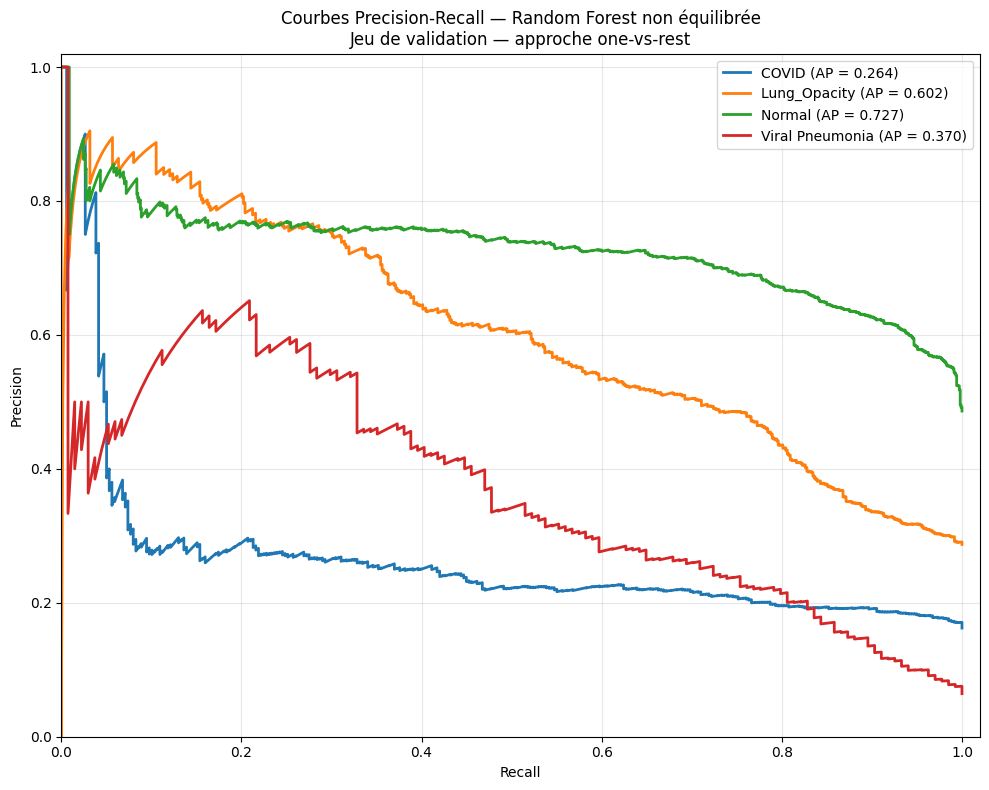

In [31]:
# Courbes Precision / Recall des 4 classes

plt.figure(figsize=(10, 8))

for class_index, class_name in enumerate(class_names):

    # Transformation one-vs-rest :
    # 1 pour la classe étudiée, 0 pour toutes les autres
    y_true_binary = (
        np.asarray(y_val) == class_name
    ).astype(int)

    # Probabilité attribuée à cette classe
    y_score = y_val_proba[:, class_index]

    precision, recall, thresholds = precision_recall_curve(
        y_true_binary,
        y_score
    )

    average_precision = average_precision_score(
        y_true_binary,
        y_score
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AP = {average_precision:.3f})"
        )
    )

plt.title(
    "Courbes Precision-Recall — Random Forest non équilibrée\n"
    "Jeu de validation — approche one-vs-rest"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.xlim(0, 1.02)
plt.ylim(0, 1.02)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Les courbes Precision-Recall montrent une bonne capacité de discrimination pour la classe Normal (AP = 0,727), suivie de Lung Opacity (AP = 0,602). Les performances restent limitées pour COVID (AP = 0,264) et Viral Pneumonia (AP = 0,370), traduisant une difficulté à distinguer ces classes des autres.

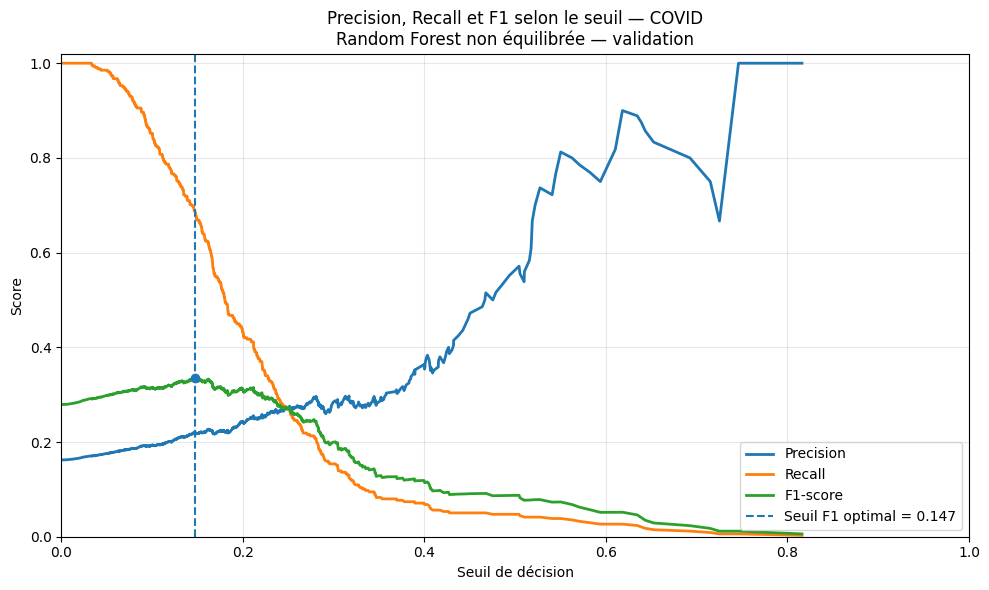

Classe : COVID
Seuil optimal : 0.1469
Precision : 0.2206
Recall : 0.6893
F1-score : 0.3343
--------------------------------------------------


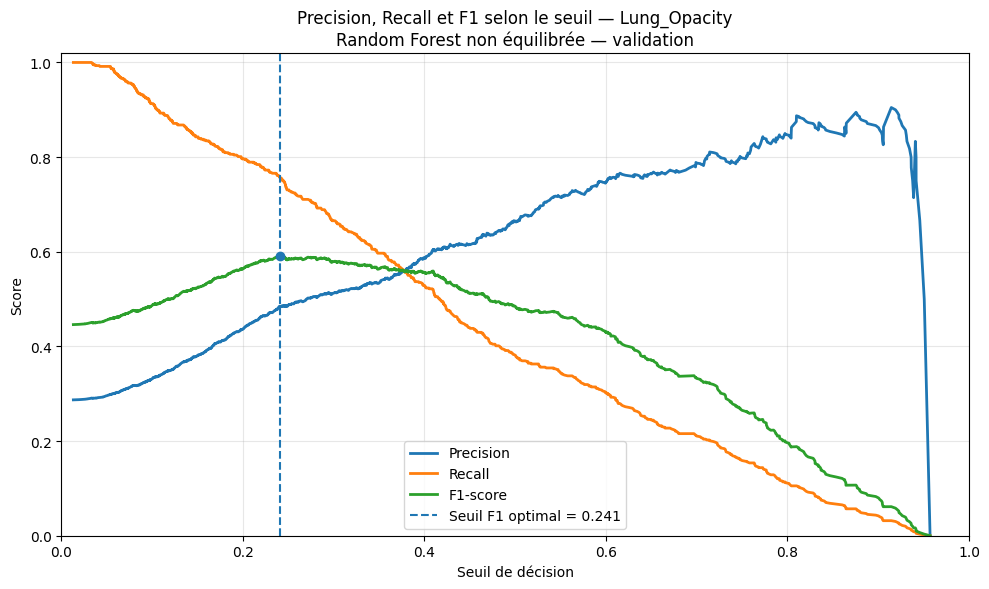

Classe : Lung_Opacity
Seuil optimal : 0.2407
Precision : 0.4845
Recall : 0.7592
F1-score : 0.5915
--------------------------------------------------


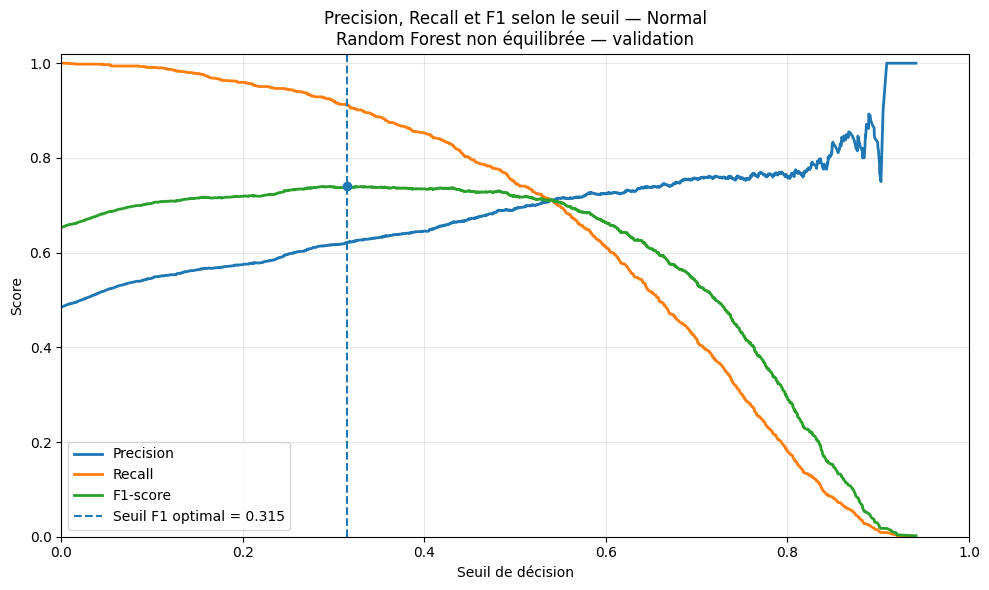

Classe : Normal
Seuil optimal : 0.3148
Precision : 0.6216
Recall : 0.9131
F1-score : 0.7397
--------------------------------------------------


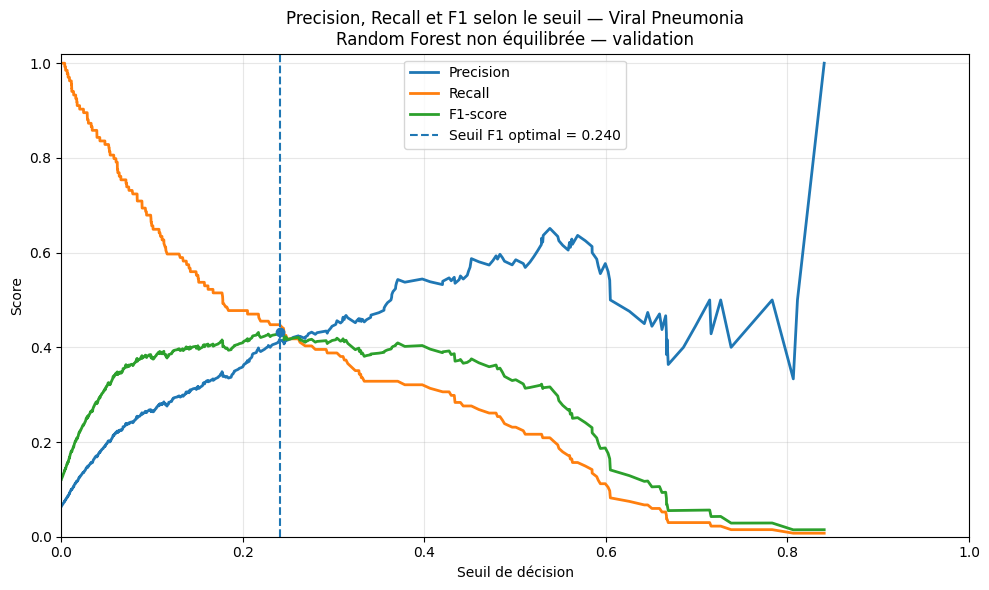

Classe : Viral Pneumonia
Seuil optimal : 0.2405
Precision : 0.4167
Recall : 0.4478
F1-score : 0.4317
--------------------------------------------------


In [33]:
# Precision, Recall et F1 en fonction du seuil

for class_index, class_name in enumerate(class_names):

    y_true_binary = (
        np.asarray(y_val) == class_name
    ).astype(int)

    y_score = y_val_proba[:, class_index]

    precision, recall, thresholds = precision_recall_curve(
        y_true_binary,
        y_score
    )

    # precision et recall contiennent une valeur de plus
    # que thresholds
    precision_by_threshold = precision[:-1]
    recall_by_threshold = recall[:-1]

    f1_by_threshold = (
        2
        * precision_by_threshold
        * recall_by_threshold
        / (
            precision_by_threshold
            + recall_by_threshold
            + 1e-12
        )
    )

    best_index = np.argmax(f1_by_threshold)

    best_threshold = thresholds[best_index]
    best_precision = precision_by_threshold[best_index]
    best_recall = recall_by_threshold[best_index]
    best_f1 = f1_by_threshold[best_index]

    plt.figure(figsize=(10, 6))

    plt.plot(
        thresholds,
        precision_by_threshold,
        label="Precision",
        linewidth=2
    )

    plt.plot(
        thresholds,
        recall_by_threshold,
        label="Recall",
        linewidth=2
    )

    plt.plot(
        thresholds,
        f1_by_threshold,
        label="F1-score",
        linewidth=2
    )

    plt.axvline(
        best_threshold,
        linestyle="--",
        label=(
            f"Seuil F1 optimal = "
            f"{best_threshold:.3f}"
        )
    )

    plt.scatter(
        best_threshold,
        best_f1,
        zorder=5
    )

    plt.title(
        f"Precision, Recall et F1 selon le seuil — {class_name}\n"
        "Random Forest non équilibrée — validation"
    )

    plt.xlabel("Seuil de décision")
    plt.ylabel("Score")

    plt.xlim(0, 1)
    plt.ylim(0, 1.02)

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Classe : {class_name}")
    print(f"Seuil optimal : {best_threshold:.4f}")
    print(f"Precision : {best_precision:.4f}")
    print(f"Recall : {best_recall:.4f}")
    print(f"F1-score : {best_f1:.4f}")
    print("-" * 50)

Le seuil optimisant le F1-score pour la classe COVID est de 0,147. À ce seuil, le modèle privilégie le rappel (68,9 %) au détriment de la précision (22,1 %), ce qui permet de détecter davantage de cas COVID mais augmente le nombre de faux positifs.